In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
df=pd.read_csv("student-mat.csv",sep=';')

### Data Cleaning

#### Check missing values (.isnull()).

In [7]:
print("Missing Values:")
df.isnull().sum

Missing Values:


<bound method DataFrame.sum of      school    sex    age  address  famsize  Pstatus   Medu   Fedu   Mjob  \
0     False  False  False    False    False    False  False  False  False   
1     False  False  False    False    False    False  False  False  False   
2     False  False  False    False    False    False  False  False  False   
3     False  False  False    False    False    False  False  False  False   
4     False  False  False    False    False    False  False  False  False   
..      ...    ...    ...      ...      ...      ...    ...    ...    ...   
390   False  False  False    False    False    False  False  False  False   
391   False  False  False    False    False    False  False  False  False   
392   False  False  False    False    False    False  False  False  False   
393   False  False  False    False    False    False  False  False  False   
394   False  False  False    False    False    False  False  False  False   

      Fjob  ...  famrel  freetime  goout   D

#### Remove duplicates.

In [27]:
dublicates=df.duplicated().sum
print("dublicates Row:",dublicates)

dublicates Row: <bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
390    False
391    False
392    False
393    False
394    False
Length: 395, dtype: bool>


In [12]:
df=df.drop_duplicates()

#### Inspect dataset shape & dtypes.

In [28]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(395, 33)


In [29]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 

In [30]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   
std   

### Analysis Questions

In [31]:
avg_grade = df['G3'].mean()
print("Average Final Grade (G3):", round(avg_grade, 2))

Average Final Grade (G3): 10.42


In [32]:
above_15 = df[df['G3'] > 15].shape[0]
print("Students scoring above 15:", above_15)

Students scoring above 15: 40


In [33]:
correlation = df['studytime'].corr(df['G3'])
print("Correlation (Study Time vs G3):", round(correlation, 3))

Correlation (Study Time vs G3): 0.098


In [34]:
gender_avg = df.groupby('sex')['G3'].mean()
print("Average Grade by Gender:")
print(gender_avg)

Average Grade by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


#### Histogram of Final Grades


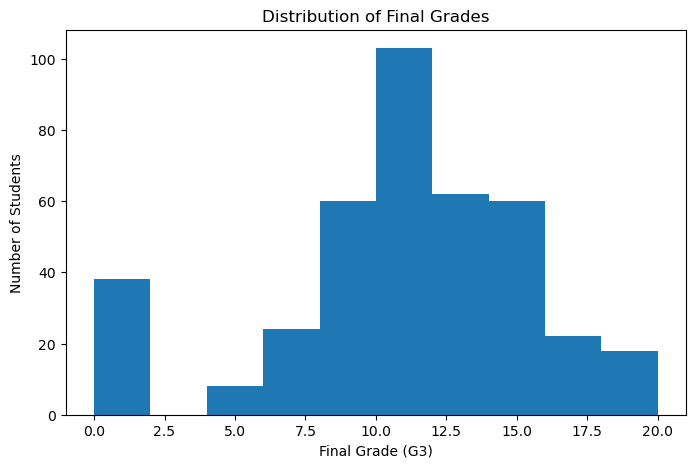

In [35]:
plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=10)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

#### Scatter Plot: Study Time vs Final Grade

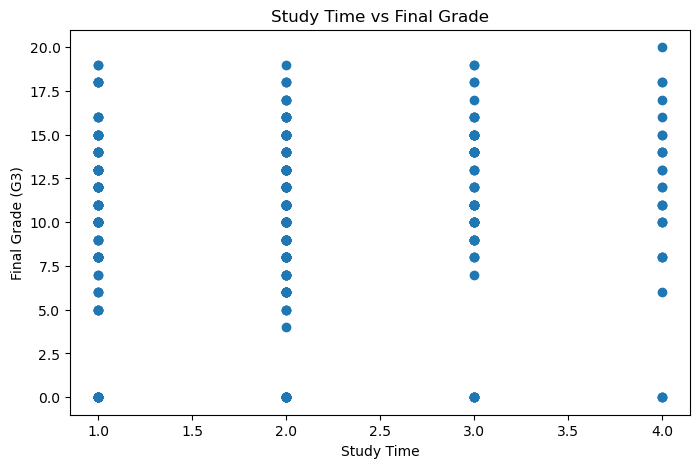

In [36]:
plt.figure(figsize=(8,5))
plt.scatter(df['studytime'], df['G3'])
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.show()

#### Bar Chart: Average Grade by Gender

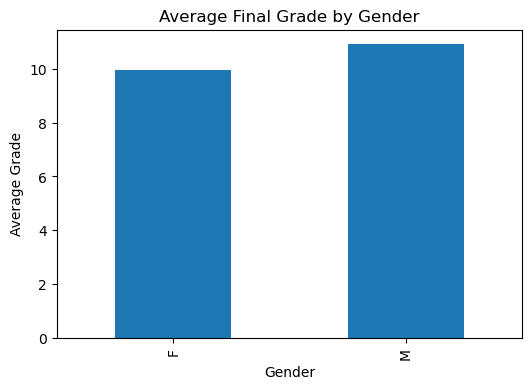

In [37]:
plt.figure(figsize=(6,4))
gender_avg.plot(kind='bar')
plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Grade")
plt.show()